In [3]:
import pandas as pd
import numpy as np

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, recall_score,
                              precision_score, f1_score)

print("✅ All libraries imported successfully!")
print(f"pandas version : {pd.__version__}")
print(f"numpy version  : {np.__version__}")

✅ All libraries imported successfully!
pandas version : 2.2.3
numpy version  : 2.1.3


In [6]:
# Load the dataset
df = pd.read_csv('Customer Churn.csv')
print(f" Data loaded! Shape: {df.shape}")
df.head()

 Data loaded! Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [5]:
print("Column names:\n", df.columns.values)

Column names:
 ['customerID' 'gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure'
 'PhoneService' 'MultipleLines' 'InternetService' 'OnlineSecurity'
 'OnlineBackup' 'DeviceProtection' 'TechSupport' 'StreamingTV'
 'StreamingMovies' 'Contract' 'PaperlessBilling' 'PaymentMethod'
 'MonthlyCharges' 'TotalCharges' 'Churn']


In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Numerical column statistics
df[['tenure', 'MonthlyCharges']].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


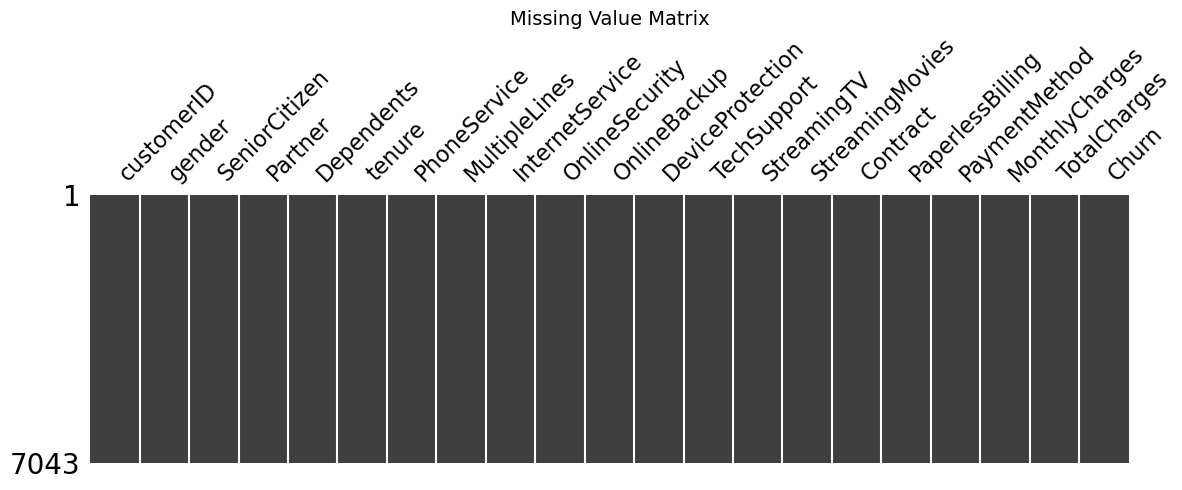


> No peculiar pattern of missingness — the data appears mostly complete.


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df, ax=ax)
plt.title('Missing Value Matrix', fontsize=14)
plt.tight_layout()
plt.show()
print("\n> No peculiar pattern of missingness — the data appears mostly complete.")

In [9]:
# Drop customerID
df = df.drop(['customerID'], axis=1)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

print("Null counts after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Null counts after conversion:
TotalCharges    11
dtype: int64


In [10]:
# View rows with TotalCharges null
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head()

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


In [11]:
# Drop rows with tenure == 0 (only 11 rows)
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)

# Fill remaining NaN with mean
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

# Map SeniorCitizen
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("Null counts after cleaning:")
print(df.isnull().sum().sum(), "total nulls remaining")
df.head()

Null counts after cleaning:
0 total nulls remaining


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


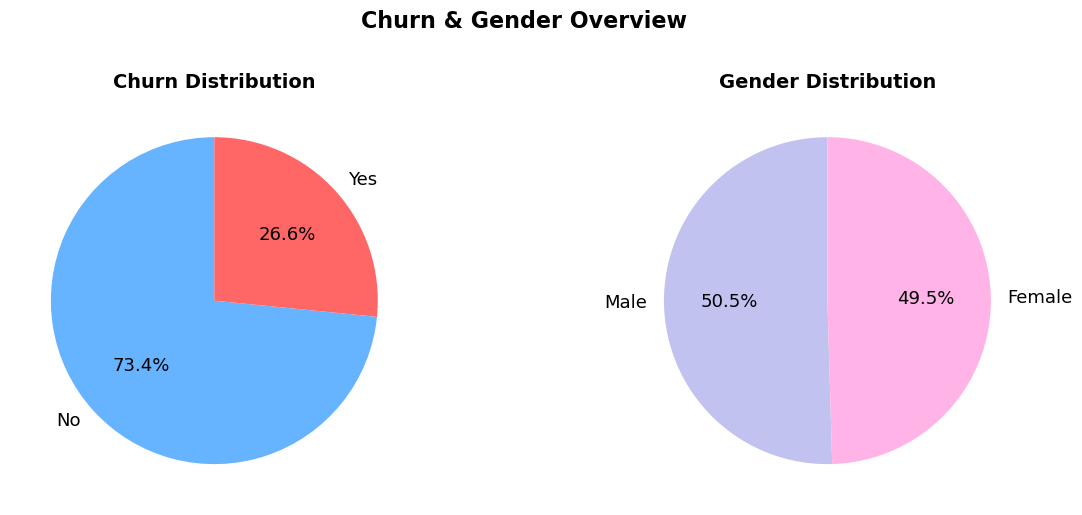


 26.6% of customers churned. Gender is nearly 50/50.


In [13]:
# Data Visualization  
# Churn & Gender Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#66b3ff','#ff6666'], startangle=90, textprops={'fontsize':13})
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

gender_counts = df['gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#c2c2f0','#ffb3e6'], startangle=90, textprops={'fontsize':13})
axes[1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Churn & Gender Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n 26.6% of customers churned. Gender is nearly 50/50.")

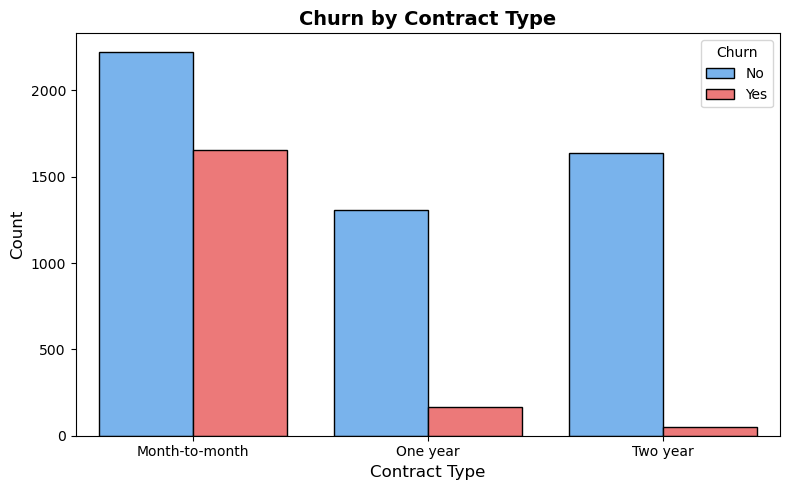


 Month-to-month contracts have far higher churn than long-term contracts.


In [14]:
# Churn by Contract Type
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn',
              palette={'No':'#66b3ff','Yes':'#ff6666'}, ax=ax, edgecolor='black')
ax.set_title('Churn by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
print("\n Month-to-month contracts have far higher churn than long-term contracts.")

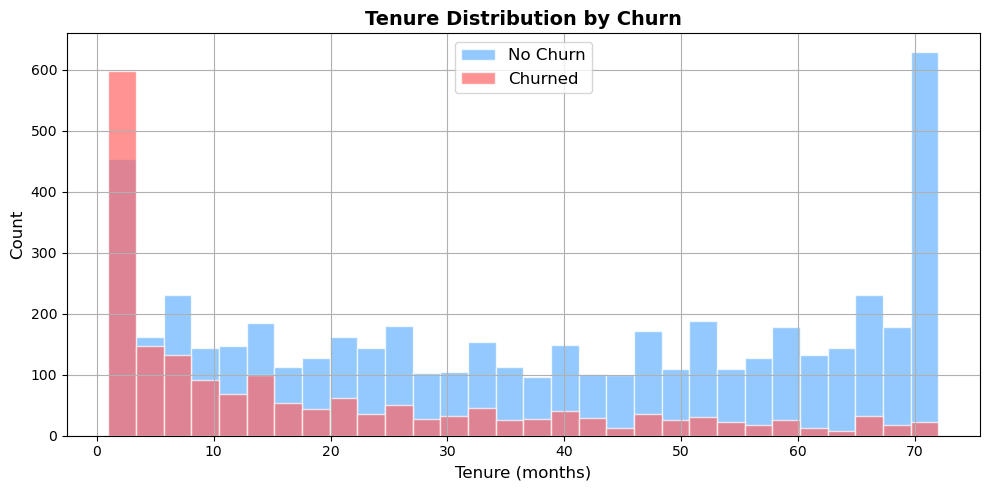


 Customers who churn tend to have lower tenure (newer customers).


In [15]:
# Tenure Distribution by Churn
fig, ax = plt.subplots(figsize=(10, 5))
df[df['Churn']=='No']['tenure'].hist(alpha=0.7, label='No Churn', color='#66b3ff', bins=30, ax=ax, edgecolor='white')
df[df['Churn']=='Yes']['tenure'].hist(alpha=0.7, label='Churned', color='#ff6666', bins=30, ax=ax, edgecolor='white')
ax.set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()
print("\n Customers who churn tend to have lower tenure (newer customers).")

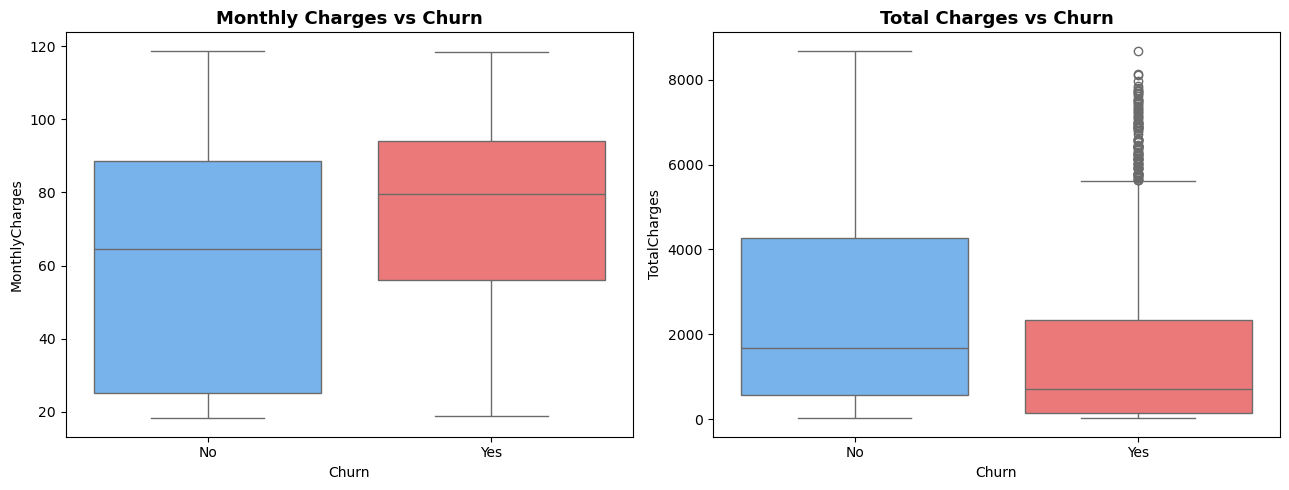


 Churned customers have higher monthly charges on average.


In [16]:
# Monthly Charges by Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No':'#66b3ff','Yes':'#ff6666'}, ax=axes[0])
axes[0].set_title('Monthly Charges vs Churn', fontsize=13, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='TotalCharges',
            palette={'No':'#66b3ff','Yes':'#ff6666'}, ax=axes[1])
axes[1].set_title('Total Charges vs Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print("\n Churned customers have higher monthly charges on average.")

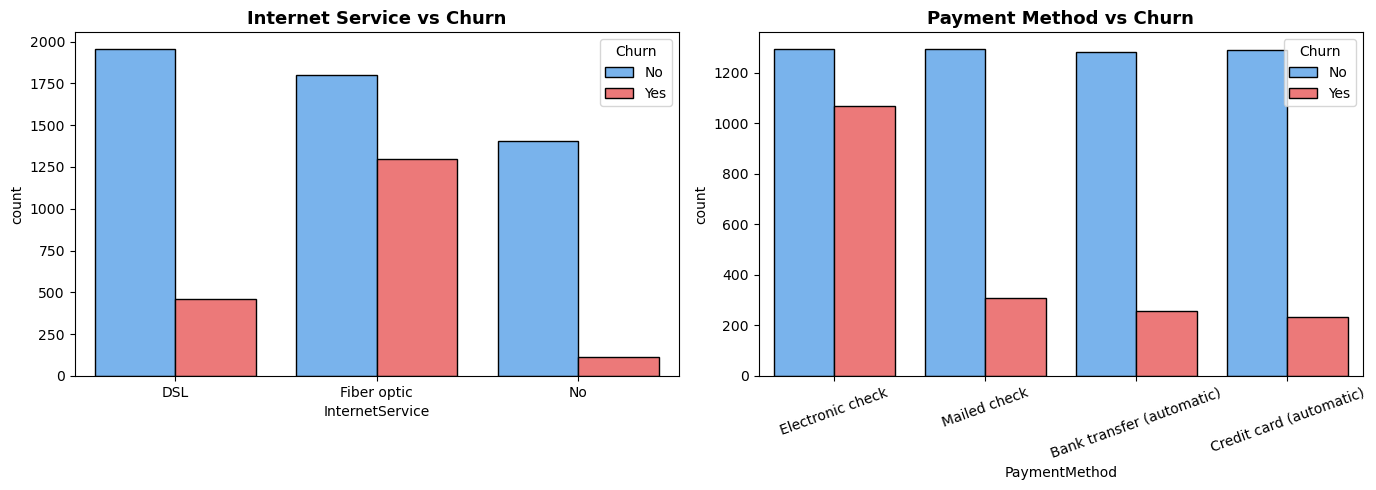


 Fiber optic users and electronic check payers churn more.


In [17]:
# Internet Service & Payment Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='InternetService', hue='Churn',
              palette={'No':'#66b3ff','Yes':'#ff6666'}, ax=axes[0], edgecolor='black')
axes[0].set_title('Internet Service vs Churn', fontsize=13, fontweight='bold')

sns.countplot(data=df, x='PaymentMethod', hue='Churn',
              palette={'No':'#66b3ff','Yes':'#ff6666'}, ax=axes[1], edgecolor='black')
axes[1].set_title('Payment Method vs Churn', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print("\n Fiber optic users and electronic check payers churn more.")

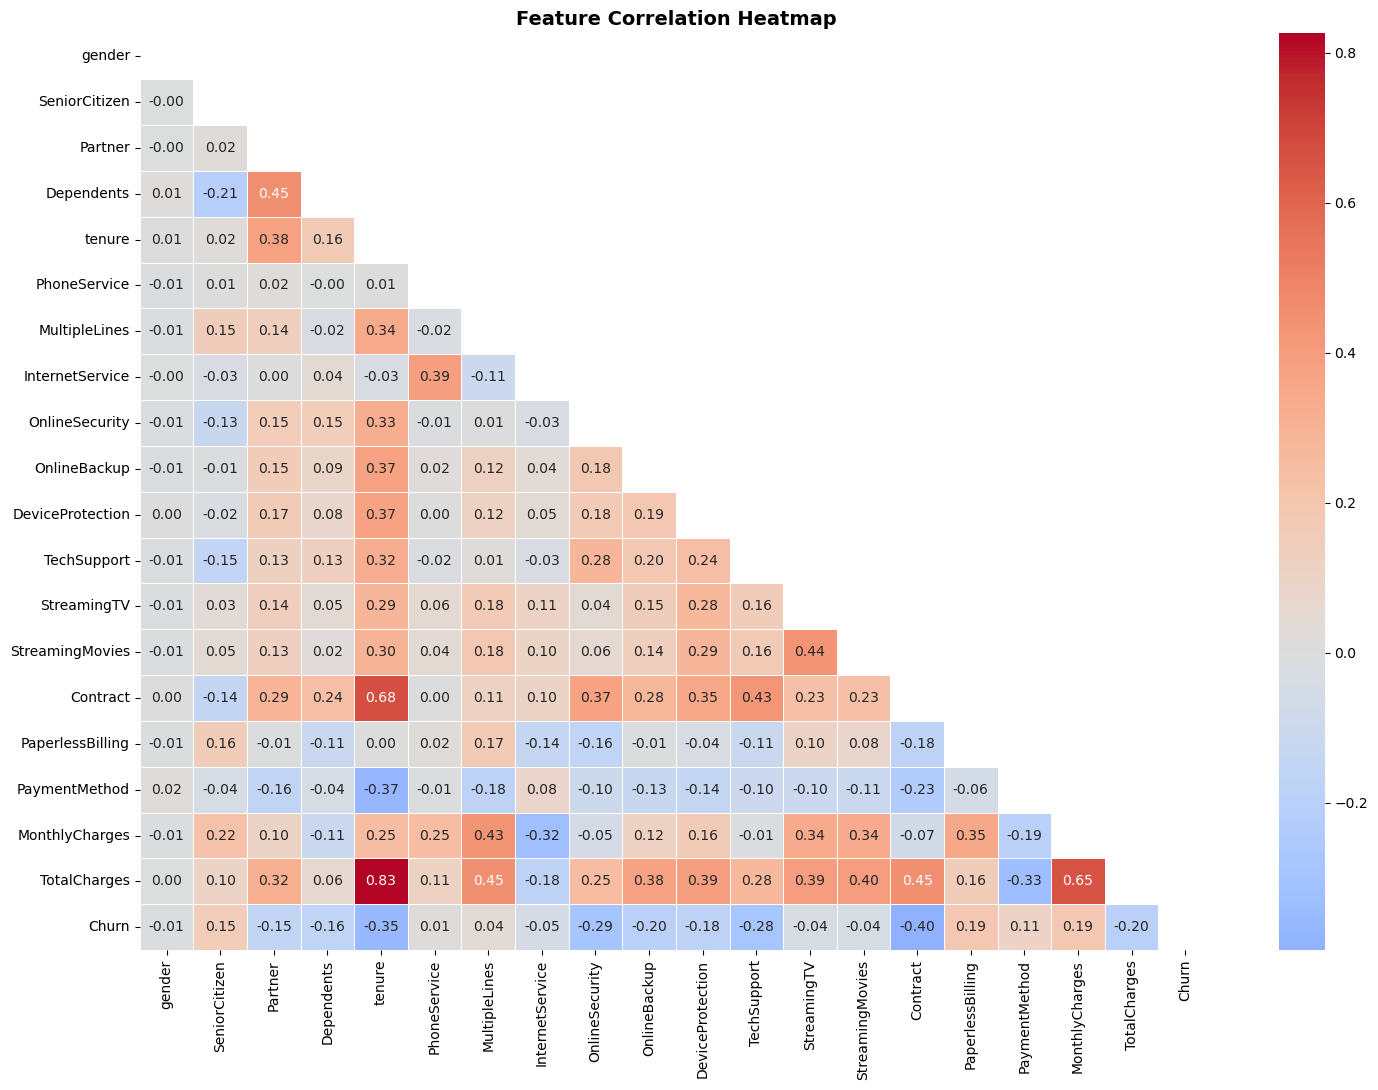

In [18]:
# Correlation Heatmap
df_num = df.copy()
le = LabelEncoder()
for col in df_num.select_dtypes(include='object').columns:
    df_num[col] = le.fit_transform(df_num[col])

fig, ax = plt.subplots(figsize=(15, 11))
corr = df_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Data Preprocessing
df_model = df.copy()
le2 = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le2.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Standardize numeric columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Train set: {X_train.shape}")
print(f" Test set : {X_test.shape}")
X_train.head()

 Train set: (5625, 19)
 Test set : (1407, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6030,0,0,0,0,0.430998,0,1,0,0,0,2,0,2,2,0,1,0,-0.523477,-0.091370
3410,1,0,0,0,-1.198760,1,0,0,0,0,0,0,2,0,0,0,1,-0.378881,-0.924111
5483,0,0,1,0,0.919926,1,2,1,0,0,2,0,0,0,0,1,2,0.430523,0.959516
5524,1,0,1,1,0.512486,1,0,0,2,0,0,2,0,0,2,0,0,-0.337331,0.119297
6337,0,0,1,1,0.919926,1,2,1,2,0,0,0,2,2,1,0,3,1.200040,1.396490


In [21]:
# Helper function
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {'Accuracy': round(acc,4), 'Precision': round(prec,4),
                     'Recall': round(rec,4), 'F1-Score': round(f1,4)}
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    return model

print(" Helper function ready!")

 Helper function ready!



  KNN
  Accuracy : 0.7662
  Precision: 0.5652
  Recall   : 0.5214
  F1-Score : 0.5424

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.57      0.52      0.54       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.69      1407
weighted avg       0.76      0.77      0.76      1407



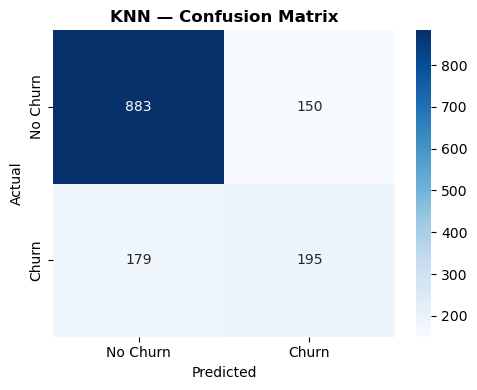

KNeighborsClassifier(n_neighbors=11)

In [22]:
evaluate_model('KNN', KNeighborsClassifier(n_neighbors=11))


  SVC
  Accuracy : 0.7946
  Precision: 0.6654
  Recall   : 0.4572
  F1-Score : 0.5420

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.67      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



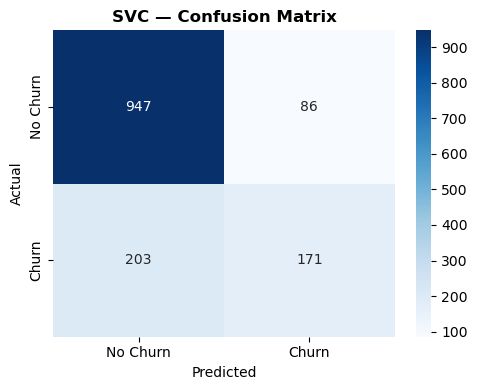

SVC(random_state=42)

In [23]:
evaluate_model('SVC', SVC(kernel='rbf', random_state=42))


  Random Forest
  Accuracy : 0.7918
  Precision: 0.6431
  Recall   : 0.4866
  F1-Score : 0.5540

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



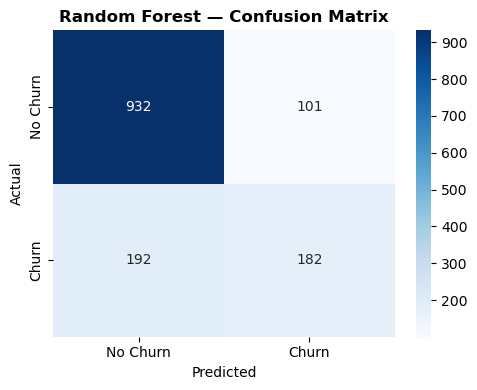

RandomForestClassifier(random_state=42)

In [24]:
evaluate_model('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42))


  Logistic Regression
  Accuracy : 0.7861
  Precision: 0.6229
  Recall   : 0.4947
  F1-Score : 0.5514

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407



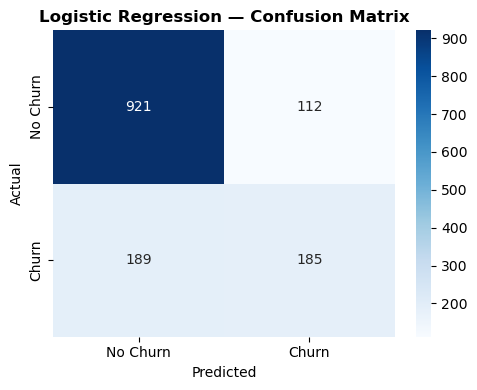

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42))


  Decision Tree
  Accuracy : 0.7264
  Precision: 0.4863
  Recall   : 0.5214
  F1-Score : 0.5032

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.52      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



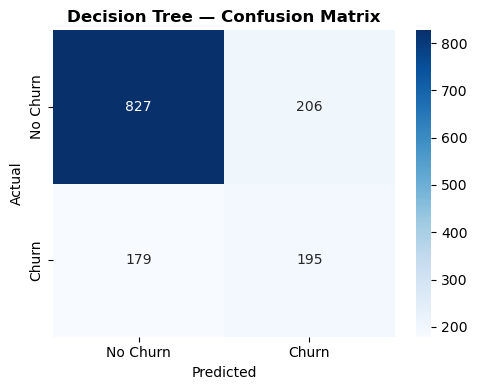

DecisionTreeClassifier(random_state=42)

In [26]:
evaluate_model('Decision Tree', DecisionTreeClassifier(random_state=42))


  AdaBoost
  Accuracy : 0.7861
  Precision: 0.6174
  Recall   : 0.5134
  F1-Score : 0.5606

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



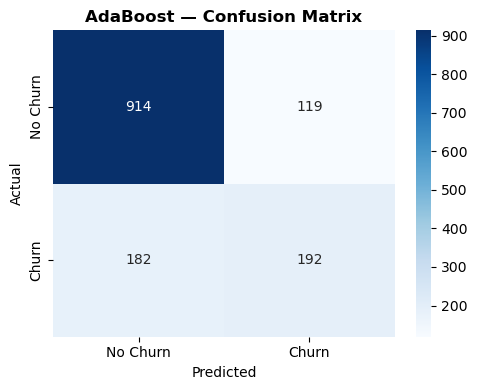

AdaBoostClassifier(n_estimators=100, random_state=42)

In [27]:
evaluate_model('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42))


  Gradient Boosting
  Accuracy : 0.7953
  Precision: 0.6525
  Recall   : 0.4920
  F1-Score : 0.5610

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.79      1407



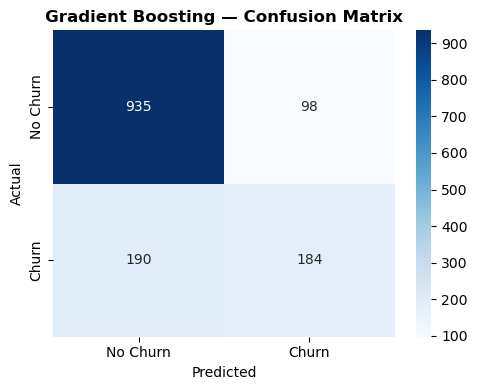

GradientBoostingClassifier(random_state=42)

In [28]:
evaluate_model('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42))


  Voting Classifier
  Accuracy : 0.8010
  Precision: 0.6715
  Recall   : 0.4920
  F1-Score : 0.5679

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



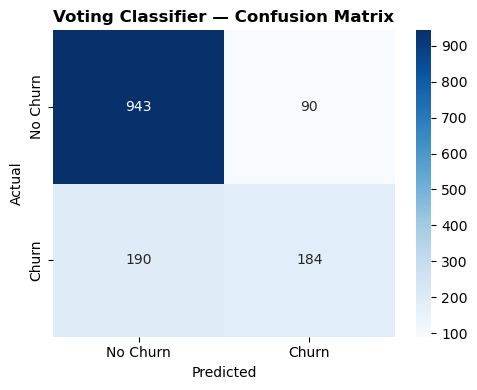

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))])

In [29]:
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = GradientBoostingClassifier(n_estimators=100, random_state=42)

evaluate_model('Voting Classifier',
    VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('gb', clf3)], voting='hard'))


=== Final Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score
Voting Classifier      0.8010     0.6715  0.4920    0.5679
Gradient Boosting      0.7953     0.6525  0.4920    0.5610
SVC                    0.7946     0.6654  0.4572    0.5420
Random Forest          0.7918     0.6431  0.4866    0.5540
AdaBoost               0.7861     0.6174  0.5134    0.5606
Logistic Regression    0.7861     0.6229  0.4947    0.5514
KNN                    0.7662     0.5652  0.5214    0.5424
Decision Tree          0.7264     0.4863  0.5214    0.5032


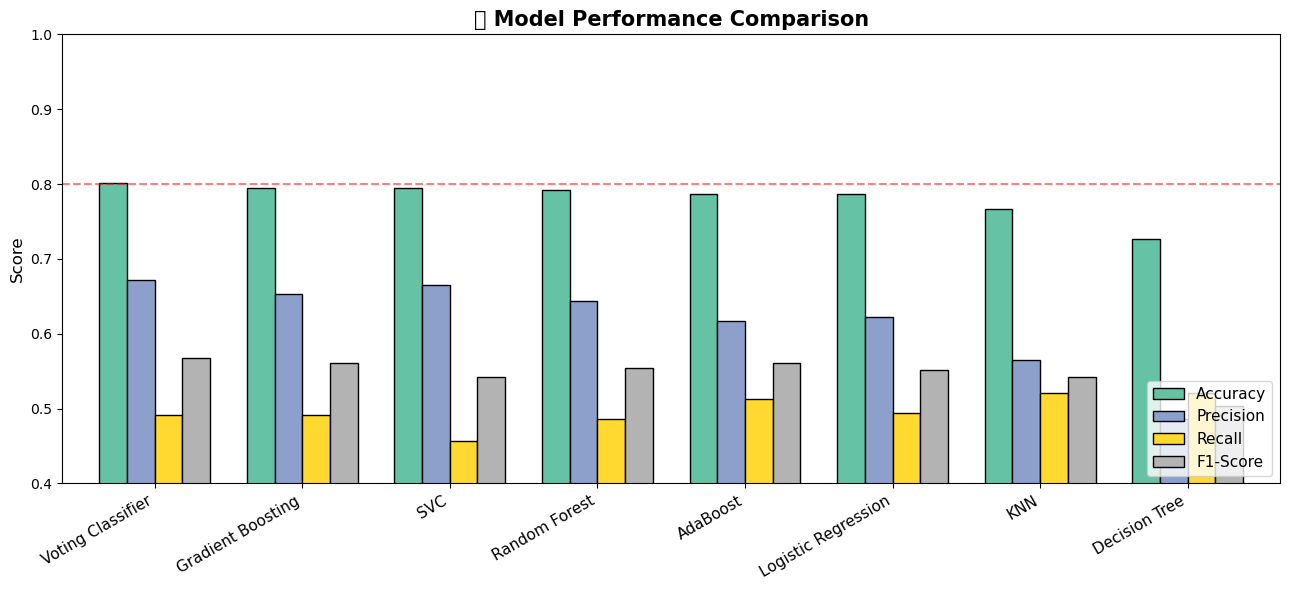


🏆 Best model: Voting Classifier with accuracy 0.8010


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print("\n=== Final Model Comparison ===")
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
results_df[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.75)
ax.set_title(' Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.4, 1.0)
ax.legend(loc='lower right', fontsize=11)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

best = results_df.index[0]
best_acc = results_df.iloc[0]['Accuracy']
print(f"\n Best model: {best} with accuracy {best_acc:.4f}")